In [2]:
%load_ext autoreload
%autoreload 2

for trials in trials, outcomes in outcomes
    preprocess
    survival-regression.fit(train, test, size_test = 70% train, 30% test)

concordance auroc 
time = 1, 2, 3, 4



In [1]:
import sys
sys.path.append('./')
sys.path.append('/Users/ASUS/Documents/GitHub/retrospective_t2e_analysis/auton-survival/')

from gls import datasets

import pandas as pd
import numpy as np

In [2]:
import pandas as pd
import torch
from tqdm import tqdm
from examples.cmhe_demo_utils import * 

c:\Users\ASUS\anaconda3\envs\Pandas\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
def load_peace_trial_data(outcome, intervention='TX'):

  cat_feats = ['GENDER', 'PHDIZZ', 'PHSYNC', 'ANARRC', 'ANTICO', 'ASANT', 'BEBLOC', 'CALCBL', 'CMOTH', 'COUGH',
               'DIABTC', 'DICONL', 'DIGITS', 'DIZZI', 'HEADAC', 'HIANGINA', 'HIANGIOG', 'HICCABG', 'HICLAUDI', 'HIDIABET', 
               'HIHYPERT', 'HIMI', 'HIPTCA', 'HPREP', 'INSLIN', 'LIPLOW', 'LVEDOC', 'MOTHER', 'NSYANG', 'ORAGEN', 
               'OTDIUR', 'QUALAB', 'QUANEF', 'POSPDI', 'SKINRA', 'SYNCOPE', 'HISTROKE', 'HITIA']

  num_feats = ['AGE', 'DIABP', 'EGFR', 'SER_CHOL', 'SER_POT', 'SYSBP', 'CIGARE', 'SDIABP', 'LVEEJF', 'HT_CM', 'WT_KG']

  feature_list = {
    'prerand.sas7bdat' : ['AGE', 'DIABP', 'EGFR', 'GENDER', 'PHDIZZ', 'PHSYNC', 'SER_CHOL', 'SER_POT', 'SYSBP'],
    'rand.sas7bdat' : ['ANARRC', 'ANTICO', 'ASANT', 'BEBLOC', 'CALCBL', 'CIGARE', 'CMOTH', 'COUGH', 'DICONL',
                      'DIGITS', 'HIANGINA', 'HICCABG', 'HICLAUDI', 'HIDIABET', 'HIHYPERT', 'HIMI', 'HIPTCA', 
                      'HISTROKE', 'HITIA', 'HPREP', 'INSLIN', 'LIPLOW', 'POSPDI', 'SDIABP', 'LVEDOC', 'LVEEJF',
                      'SKINRA', 'SYNCOP', 'TX', 'WT_KG', 'HT_CM', 'DIABTC', 'DIZZIN', 'HEADAC', 'HIANGIOG',
                      'MOTHER', 'NSYANG', 'ORAGEN', 'OTDIUR', 'QUALAB', 'QUANEF', 'SSYSBP']
  }

  if outcome is 'PRIMARY': outcomedt = 'PRIMRYDT'
  else: outcomedt = outcome+'DT'

  outcomes, _ = datasets._load_generic_biolincc_dataset('outcomes.sas7bdat', 
                                                         outcomedt, outcome,
                                                         features=feature_list, 
                                                         id_col='NEW_ID',
                                                         location='datasets/PEACE/Data/')
                                                                  
  outcomes2, features = datasets._load_generic_biolincc_dataset('outcomes.sas7bdat', 
                                                                'DAYSSINCERAND', outcome,
                                                                features=feature_list, 
                                                                id_col='NEW_ID',
                                                                location='datasets/PEACE/Data/')
  # When the outcome occurs we use the time to the outcome. 
  # Incase the outcome doesn't occur, we consider the time since randomization
  # # to last followup as the censoring time.
  outcomes.loc[outcomes.event == 0.0, 'time'] = outcomes2.loc[outcomes.event == 0.0,'time']

  # Convert Censoring Indicator to Binary
  # ie. 1 = Event, 0 = Censored
  outcomes.event = outcomes.event == 1.0 

  NaNindex = pd.isna(outcomes.time)
  outcomes = outcomes.loc[~NaNindex]
  features = features.loc[~NaNindex]
  
  intervention = features[intervention]

  intervention[intervention == 1.0] = 'Trandolapril'
  intervention[intervention == 0.0] = 'Placebo'
  
  features = features.loc[:, features.columns != 'TX']

  features = features.rename(columns={"AGE": "Age",
                                      "DIABP": "Seated_Diastolic_Blood_Pressure", 
                                      "PHDIZZ": "History_Dizziness",
                                      "EGFR": "Estimated_Glomerular_Filtration_Rate",
                                      "GENDER": "Sex",
                                      "PHSYNC": "History_Syncope",
                                      "SER_POT": "Serum_Potassium",
                                      "SER_CHOL": "Cholesterol", 
                                      "SYSBP": "Seated_Systolic_Blood_Pressure", 
                                      "ASANT": "Use_Aspirin/Antiplatelet_Therapy", 
                                      "CIGARE": "Baseline_Smoke_status", 
                                      "ANARRC": "Use_Anti_Arrhythmic", 
                                      "ANTICO": "Use_Anticoagulants", 
                                      "BEBLOC": "Beta_Blocker", 
                                      "CALCBL": "Calcium_Blocker", 
                                      "CMOTH": "Use_Other_Cardiac_Medication", 
                                      "COUGH": "Cough",
                                      "DIABTC": "Known_Diabetic",
                                      "HIDIABET": "History_Diabetes", 
                                      "DICONL": "Use_Diet_Control", 
                                      "DIGITS": "Use_Digitalis", 
                                      "DIZZIN": "Dizziness",
                                      "HEADAC": "Headache",
                                      "HIANGINA": "History_Angina",
                                      "HIANGIOG": "Angiographic_Coronary_Disease",
                                      'HICCABG': "History_Coronary_Artery_Bypass_Graft", 
                                      'HICLAUDI': "History_Intermittent_Claudication", 
                                      'HIHYPERT': "History_Hypertension", 
                                      'HIMI': "History_Myocardial_Infarction", 
                                      'HIPTCA': "History_Percutaneous_Transluminal_Coronary_Angioplasty", 
                                      'HISTROKE': "History_Stroke", 
                                      'HITIA': "History_Transient_Ischemic_Attack", 
                                      'HPREP': "Use_Hormone_Replacement_Therapy", 
                                      'INSLIN': "Use_Insulin", 
                                      'LIPLOW': "Use_Lipid_Lowering_Therapy",
                                      "LVEDOC": "Left_Ventricular_Evaluation_Documented_By",
                                      "LVEEJF": "Left_Ventricular_Ejection_Fraction",
                                      "MOTHER": "Use_Other_Noncardiac_Medication",
                                      "NSYANG": "Canadian_Cardiovascular_Society_Classification",
                                      "ORAGEN": "Use_Oral_Agents",
                                      "OTDIUR": "Use_Other_Diuretics", 
                                      'WT_KG': "Weight_KG", 
                                      'HT_CM': "Height_CM",
                                      'POSPDI': "Use_Potassium_Sparing_Diuretics", 
                                      "QUALAB": "Left_Ventricular_Function_Qualitative_Abnormal",
                                      "QUANEF": "Quantitative_Ejection_Fraction",
                                      'SKINRA': "Skin_Rash", 
                                      'SYNCOP': "Syncope"})
  
  features["Sex"].replace({1.0: "Female", 2.0: "Male"}, inplace=True)
  features['Baseline_Smoke_status'].replace({1.0: "Current", 2.0: "Ever", 3.0: "Never"}, inplace=True)
  features['Left_Ventricular_Evaluation_Documented_By'].replace({1.0: "Contrast_Ventriculography", 
                                                                 2.0: "Radionuclide_Ventriculography", 
                                                                 3.0: "Echocardiogram"}, inplace=True)
  features['Canadian_Cardiovascular_Society_Classification'].replace({1.0: "No symptoms of angina", 2.0: "I", 3.0: "II",
                                                                      4.0: "III+", 5.0: "III+"}, inplace=True)

  cols = ['History_Dizziness', 
          'History_Syncope', 
          'Use_Aspirin/Antiplatelet_Therapy', 
          'Use_Anti_Arrhythmic', 
          'Use_Anticoagulants', 
          'Beta_Blocker', 
          'Calcium_Blocker', 
          'Use_Other_Cardiac_Medication',
          'Cough',
          'Use_Other_Cardiac_Medication', 
          'Known_Diabetic',
          'History_Diabetes', 
          'Dizziness',
          'Headache',
          'Use_Diet_Control', 
          'Use_Digitalis', 
          'History_Angina', 
          'Angiographic_Coronary_Disease',
          'History_Coronary_Artery_Bypass_Graft', 
          'History_Intermittent_Claudication', 
          'History_Hypertension', 
          'History_Myocardial_Infarction', 
          'History_Percutaneous_Transluminal_Coronary_Angioplasty', 
          'History_Stroke', 
          'History_Transient_Ischemic_Attack', 
          'Use_Hormone_Replacement_Therapy', 
          'Use_Insulin', 
          'Use_Other_Noncardiac_Medication',
          'Use_Lipid_Lowering_Therapy', 
          'Use_Potassium_Sparing_Diuretics', 
          'Skin_Rash', 
          'Syncope',
          'Use_Oral_Agents',
          'Use_Other_Diuretics',
          'Use_Potassium_Sparing_Diuretics',
          'Left_Ventricular_Function_Qualitative_Abnormal']
  for col in cols:
    features[col].replace({1.0: "Yes", 2.0: "No"}, inplace=True)
  
  return outcomes, features, intervention, cat_feats, num_feats

<>:19: SyntaxWarning: "is" with a literal. Did you mean "=="?
<>:19: SyntaxWarning: "is" with a literal. Did you mean "=="?
C:\Users\ASUS\AppData\Local\Temp\ipykernel_35160\3665903100.py:19: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if outcome is 'PRIMARY': outcomedt = 'PRIMRYDT'


In [8]:
# Load the synthetic dataset
outcomes, features, intervention, cat_feats, num_feats = load_peace_trial_data(outcome='PRIMARY')

# Let's take a look at take the dataset
features.head()

(8290, 9)
(8290, 42)
(8290, 9)
(8290, 42)


,Use_Diet_Control,Calcium_Blocker,Seated_Systolic_Blood_Pressure,Use_Hormone_Replacement_Therapy,Headache,History_Syncope,Use_Other_Noncardiac_Medication,Serum_Potassium,History_Hypertension,Use_Potassium_Sparing_Diuretics,...,History_Dizziness,Age,Left_Ventricular_Evaluation_Documented_By,History_Intermittent_Claudication,Quantitative_Ejection_Fraction,Sex,SDIABP,SSYSBP,Weight_KG,Use_Other_Cardiac_Medication
NEW_ID,,,,,,,,,,,,,,,,,,,,,
10007.0,NaN,No,150.0,NaN,No,No,No,4.8,Yes,No,...,No,58.0,Echocardiogram,No,1.0,Male,80.0,150.0,72.0,No
10026.0,NaN,Yes,144.0,NaN,No,No,Yes,4.3,Yes,No,...,No,68.0,Echocardiogram,No,1.0,Male,91.0,142.0,107.0,Yes
10027.0,NaN,No,140.0,NaN,No,No,No,4.8,No,No,...,No,65.0,Echocardiogram,No,1.0,Male,70.0,115.0,84.0,Yes
10040.0,NaN,Yes,184.0,NaN,No,No,Yes,4.4,Yes,No,...,No,64.0,Contrast_Ventriculography,Yes,NaN,Male,82.0,140.0,85.0,NaN
10042.0,NaN,Yes,110.0,NaN,No,No,Yes,4.3,No,No,...,No,61.0,Echocardiogram,No,1.0,Male,78.0,126.0,83.0,No


In [11]:
features.Known_Diabetic.value_counts()

No     6918
Yes    1371
Name: Known_Diabetic, dtype: int64

In [12]:
features.History_Diabetes.value_counts()

No     6909
Yes    1380
Name: History_Diabetes, dtype: int64

In [9]:
features.Seated_Diastolic_Blood_Pressure

NEW_ID
10007.0     80.0
10026.0     86.0
10027.0     80.0
10040.0    102.0
10042.0     70.0
           ...  
99957.0     88.0
99959.0     76.0
99968.0     80.0
99980.0     74.0
99984.0     80.0
Name: Seated_Diastolic_Blood_Pressure, Length: 8290, dtype: float64

In [10]:
features.SSYSBP

NEW_ID
10007.0    150.0
10026.0    142.0
10027.0    115.0
10040.0    140.0
10042.0    126.0
           ...  
99957.0    177.0
99959.0    130.0
99968.0    135.0
99980.0    155.0
99984.0    148.0
Name: SSYSBP, Length: 8290, dtype: float64

In [42]:
intervention

NEW_ID
10007.0    1.0
10026.0    0.0
10027.0    0.0
10040.0    0.0
10042.0    1.0
          ... 
99957.0    0.0
99959.0    1.0
99968.0    1.0
99980.0    0.0
99984.0    1.0
Name: TX, Length: 8290, dtype: float64

In [60]:
y

,time,event
NEW_ID,,
10007.0,1641.0,False
10026.0,919.0,False
10027.0,1631.0,False
10040.0,2316.0,True
10042.0,917.0,True
...,...,...
99957.0,2386.0,False
99959.0,2010.0,False
99968.0,1661.0,False


In [61]:
x

,Potassium_Sparing_Diuretics,History_Dizziness,Insulin,History_Angina,Skin_Rash,History_Diabetes,Calcium_Blocker,Beta_Blocker,Age,History_Coronary_Artery_Bypass_Graft,...,Lipid_Lowering_Therapy,Intervention,Sex,SDIABP,Hist_Myocardial_Infarction,Anticoagulants,Hormone_Replacement_Therapy,History_Percutaneous_Transluminal_Coronary_Angioplasty,Height_CM,Systolic_Blood_Pressure
NEW_ID,,,,,,,,,,,,,,,,,,,,,
10007.0,No,No,NaN,Yes,No,Yes,No,Yes,58.0,No,...,No,Trandolapril,Male,80.0,Yes,No,NaN,No,164.0,150.0
10026.0,No,No,NaN,Yes,No,No,Yes,Yes,68.0,Yes,...,Yes,Placebo,Male,91.0,Yes,No,NaN,No,175.0,144.0
10027.0,No,No,NaN,Yes,No,No,No,Yes,65.0,No,...,Yes,Placebo,Male,70.0,No,No,NaN,Yes,170.0,140.0
10040.0,No,No,NaN,Yes,No,No,Yes,No,64.0,No,...,Yes,Placebo,Male,82.0,No,No,NaN,No,178.0,184.0
10042.0,No,No,NaN,Yes,No,No,Yes,No,61.0,No,...,No,Trandolapril,Male,78.0,No,No,NaN,Yes,173.0,110.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99957.0,No,No,NaN,No,No,No,No,Yes,83.0,No,...,Yes,Placebo,Male,99.0,No,No,NaN,No,181.0,142.0
99959.0,No,No,NaN,Yes,No,No,No,Yes,62.0,Yes,...,Yes,Trandolapril,Male,64.0,Yes,No,NaN,Yes,175.0,134.0
99968.0,No,No,NaN,No,No,No,Yes,No,79.0,No,...,No,Trandolapril,Male,80.0,Yes,No,NaN,Yes,157.0,140.0


In [4]:
y.head()

,time,event
NEW_ID,,
10007.0,1641.0,False
10026.0,919.0,False
10027.0,1631.0,False
10040.0,2507.0,True
10042.0,1283.0,True


In [4]:
interventions = x['TX']
interventions

NEW_ID
10007.0    1.0
10026.0    0.0
10027.0    0.0
10040.0    0.0
10042.0    1.0
          ... 
99957.0    0.0
99959.0    1.0
99968.0    1.0
99980.0    0.0
99984.0    1.0
Name: TX, Length: 8290, dtype: float64

In [5]:
from preprocessing import Preprocessor

cat_feats = ['GENDER', 'PHDIZZ', 'PHSYNC', 'ANARRC', 'ANTICO', 'ASANT', 'BEBLOC', 'CALCBL', 'CIGARE', 'CMOTH', 'COUGH',
            'DIABTC', 'DICONL', 'DIGITS', 'DIZZIN', 'HEADAC', 'HIANGINA', 'HIANGIOG', 'HICCABG', 'HICLAUDI', 'HIDIABET', 
            'HIHYPERT', 'HIMI', 'HIPTCA', 'HISTROKE', 'HITIA', 'HPREP', 'INSLIN', 'LIPLOW', 'LVEDOC', 'MOTHER', 'NSYANG', 
            'ORAGEN', 'OTDIUR', 'POSPDI', 'QUALAB', 'QUANEF', 'SKINRA', 'SYNCOP', 'TX']
num_feats = ['AGE', 'DIABP', 'SER_CHOL', 'SER_POT', 'SYSBP', 'HT_CM', 'WT_KG', 'LVEEJF', 'SDIABP', 'SSYSBP']

features = Preprocessor().fit_transform(x[cat_feats+num_feats], cat_feats=cat_feats, num_feats=num_feats)

In [6]:
features.head()

,AGE,DIABP,SER_CHOL,SER_POT,SYSBP,HT_CM,WT_KG,LVEEJF,SDIABP,SSYSBP,...,NSYANG_2.0,NSYANG_3.0,NSYANG_4.0,OTDIUR_2.0,POSPDI_2.0,QUALAB_2.0,QUANEF_2.0,SKINRA_2.0,SYNCOP_2.0,TX_1.0
NEW_ID,,,,,,,,,,,,,,,,,,,,,
10007.0,-0.772874,0.231144,4.446837,1.167544,0.998920,-0.795646,-0.733583,-1.110398,0.570418,1.364896,...,1,0,0,1,1,0,0,1,1,1
10026.0,0.447554,0.844730,-0.921682,-0.116972,0.637416,0.391114,1.502575,-1.438520,1.712760,0.880148,...,1,0,0,1,1,0,0,1,1,0
10027.0,0.081426,0.231144,0.446764,1.167544,0.396414,-0.148322,0.033100,-1.438520,-0.468074,-0.755875,...,0,0,0,1,1,0,0,1,1,0
10040.0,-0.040617,2.480960,-0.895366,0.139932,3.047438,0.714777,0.096990,1.733321,0.778117,0.758962,...,1,0,0,1,1,0,0,1,1,0
10042.0,-0.406746,-0.791499,-0.684836,-0.116972,-1.411102,0.175340,-0.030790,0.202088,0.362720,-0.089347,...,0,0,0,1,1,1,0,1,1,1


In [7]:
# Hyper-parameters to train model
k = 1 # number of underlying base survival phenotypes
g = 2 # number of underlying treatment effect phenotypes.
layers = [] # number of neurons in each hidden layer.

random_seed = 3
iters = 100 # number of training epochs
learning_rate = 0.001
batch_size = 256 
vsize = 0.15 # size of the validation split
patience = 5
optimizer = "Adam"
gate_l2_penalty = 1e-3

In [8]:
from sklearn.model_selection import train_test_split

# Split the data into train and test sets
x_train, x_test, y_train, y_test = train_test_split(features, y, test_size=0.5, random_state=1, stratify = y.event + 2*interventions) 

print(f'Number of training data points: {len(x_train)}')
print(f'Number of test data points: {len(x_test)}')

Number of training data points: 4145
Number of test data points: 4145


In [32]:
x_tr = (x_train.loc[:, x_train.columns != 'TX_1.0']).values.astype('float32')
t_tr = y_train['time'].values.astype('float32')
e_tr = y_train['event'].values.astype('float32')
a_tr = x_train['TX_1.0'].values.astype('float32')

In [33]:
x_te = (x_test.loc[:, x_test.columns != 'TX_1.0']).values.astype('float32')
t_te = y_test['time'].values.astype('float32')
e_te = y_test['event'].values.astype('float32')
a_te = x_test['TX_1.0'].values.astype('float32')

In [34]:
from auton_survival.models.cmhe import DeepCoxMixturesHeterogenousEffects

torch.manual_seed(random_seed)
np.random.seed(random_seed)

# Instantiate the CMHE model
model = DeepCoxMixturesHeterogenousEffects(random_seed=5, k=k, g=g, layers=layers, gate_l2_penalty=gate_l2_penalty)

model = model.fit(x_tr, t_tr, e_tr, a_tr, vsize=vsize, val_data=None, iters=iters, 
                  learning_rate=learning_rate, batch_size=batch_size, 
                  optimizer=optimizer, patience=patience)

  0%|          | 0/100 [00:00<?, ?it/s]c:\Users/ASUS/Documents/GitHub/retrospective_t2e_analysis/auton-survival\auton_survival\models\cmhe\cmhe_utilities.py:121: RuntimeWarning: invalid value encountered in log
  probs.append(np.log(event_probs))
100%|██████████| 100/100 [00:20<00:00,  4.83it/s]


In [6]:
from auton_survival import reporting
import matplotlib.pyplot as plt

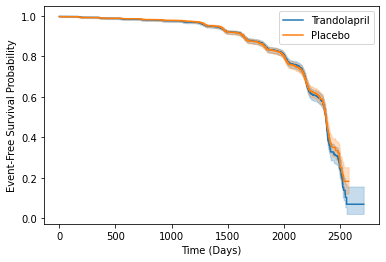

In [11]:
y.event = ~y.event
axx = reporting.plot_kaplanmeier(y, x.Intervention)
h, l = axx.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Trandolapril', 'Placebo'], loc="upper right")
plt.show()
pass

In [9]:
y.event

NEW_ID
10007.0    False
10026.0    False
10027.0    False
10040.0     True
10042.0     True
           ...  
99957.0    False
99959.0    False
99968.0    False
99980.0    False
99984.0    False
Name: event, Length: 8290, dtype: bool

In [37]:
zeta_probs_train = model.predict_latent_phi(x_tr)
q = [0.9, 0.8, 0.7, 0.6]
zeta_train_qt = np.quantile(zeta_probs_train[:, 0], q)
idx_list_qt10 = np.where(zeta_probs_train[:, 0] >= zeta_train_qt[0])
idx_list_qt20 = np.where(zeta_probs_train[:, 0] >= zeta_train_qt[1])
idx_list_qt30 = np.where(zeta_probs_train[:, 0] >= zeta_train_qt[2])
idx_list_qt40 = np.where(zeta_probs_train[:, 0] >= zeta_train_qt[3])

In [38]:
zeta_probs_test = model.predict_latent_phi(x_te)
zeta_test_qt = np.quantile(zeta_probs_test[:, 0], q)
idx_list_qt10te = np.where(zeta_probs_test[:, 0] >= zeta_test_qt[0])
idx_list_qt20te = np.where(zeta_probs_test[:, 0] >= zeta_test_qt[1])
idx_list_qt30te = np.where(zeta_probs_test[:, 0] >= zeta_test_qt[2])
idx_list_qt40te = np.where(zeta_probs_test[:, 0] >= zeta_test_qt[3])

In [39]:
# zeta 1
zeta_train_qt1 = np.quantile(zeta_probs_train[:, 1], q)
idx_list_qt10_1 = np.where(zeta_probs_train[:, 1] >= zeta_train_qt1[0])
idx_list_qt20_1 = np.where(zeta_probs_train[:, 1] >= zeta_train_qt1[1])
idx_list_qt30_1 = np.where(zeta_probs_train[:, 1] >= zeta_train_qt1[2])
idx_list_qt40_1 = np.where(zeta_probs_train[:, 1] >= zeta_train_qt1[3])

In [40]:
# zeta 1
zeta_test_qt1 = np.quantile(zeta_probs_test[:, 1], q)
idx_list_qt10te_1 = np.where(zeta_probs_test[:, 1] >= zeta_test_qt1[0])
idx_list_qt20te_1 = np.where(zeta_probs_test[:, 1] >= zeta_test_qt1[1])
idx_list_qt30te_1 = np.where(zeta_probs_test[:, 1] >= zeta_test_qt1[2])
idx_list_qt40te_1 = np.where(zeta_probs_test[:, 1] >= zeta_test_qt1[3])

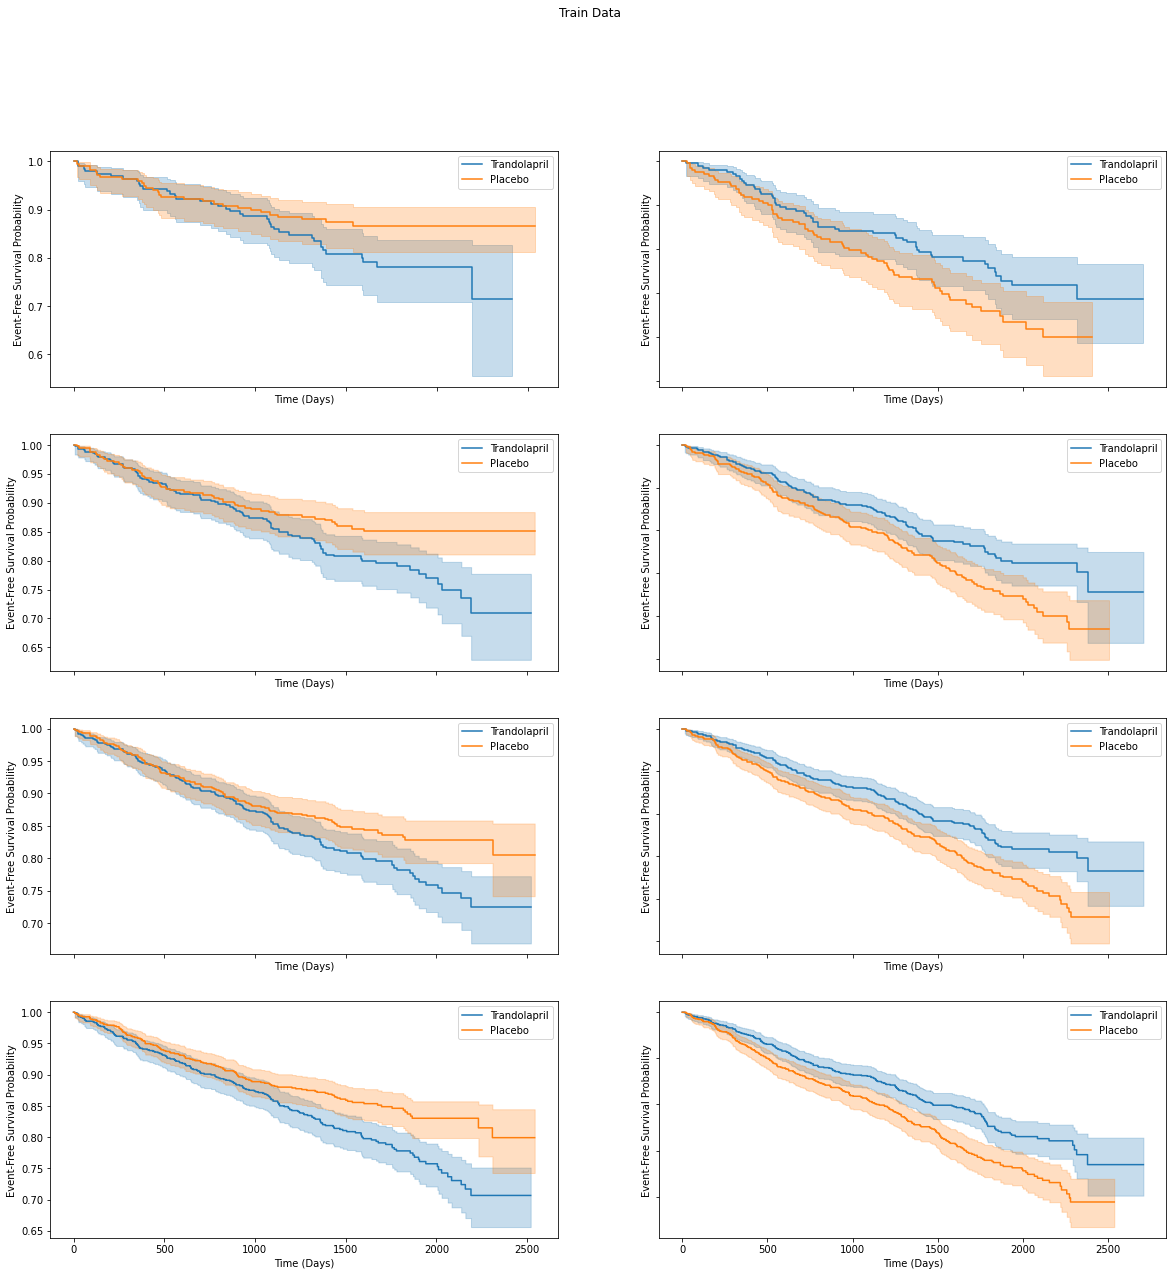

In [41]:
fig, ((ax5, ax13), (ax6, ax14), (ax7, ax15), (ax8, ax16)) = plt.subplots(4, 2, figsize= (20, 20))
fig.suptitle('Train Data')
reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt10], x_train['TX_1.0'].iloc[idx_list_qt10], ax=ax5)
reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt20], x_train['TX_1.0'].iloc[idx_list_qt20], ax=ax6)
reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt30], x_train['TX_1.0'].iloc[idx_list_qt30], ax=ax7) 
reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt40], x_train['TX_1.0'].iloc[idx_list_qt40], ax=ax8)
reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt10_1], x_train['TX_1.0'].iloc[idx_list_qt10_1], ax=ax13)
reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt20_1], x_train['TX_1.0'].iloc[idx_list_qt20_1], ax=ax14)
reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt30_1], x_train['TX_1.0'].iloc[idx_list_qt30_1], ax=ax15)
reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt40_1], x_train['TX_1.0'].iloc[idx_list_qt40_1], ax=ax16) 
for ax in fig.get_axes():
    ax.label_outer()
    h, l = ax.get_legend_handles_labels()
    ax.set_xlabel('Time (Days)')
    ax.set_ylabel('Event-Free Survival Probability')
    ax.legend([h[0], h[1]], ['Trandolapril', 'Placebo'], loc="upper right")
plt.show()

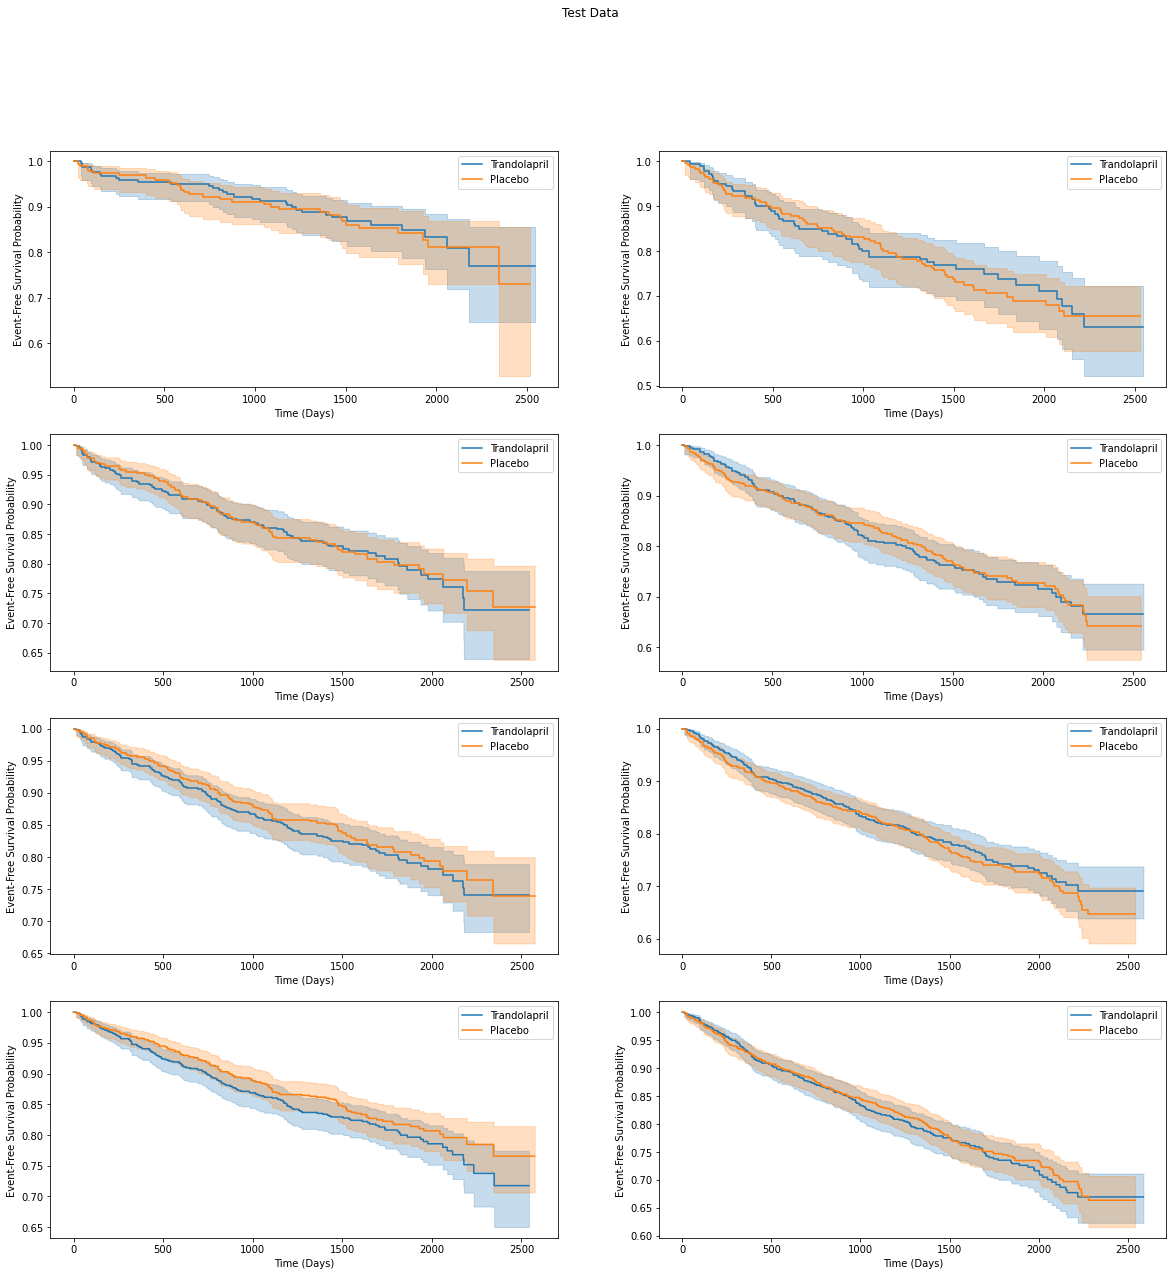

In [42]:
fig, ((ax9, ax17), (ax10, ax18), (ax11, ax19), (ax12, ax20)) = plt.subplots(4, 2, figsize= (20, 20))
fig.suptitle('Test Data')
reporting.plot_kaplanmeier(y_test.iloc[idx_list_qt10te], x_test['TX_1.0'].iloc[idx_list_qt10te], ax=ax9)
reporting.plot_kaplanmeier(y_test.iloc[idx_list_qt20te], x_test['TX_1.0'].iloc[idx_list_qt20te], ax=ax10)
reporting.plot_kaplanmeier(y_test.iloc[idx_list_qt30te], x_test['TX_1.0'].iloc[idx_list_qt30te], ax=ax11)
reporting.plot_kaplanmeier(y_test.iloc[idx_list_qt40te], x_test['TX_1.0'].iloc[idx_list_qt40te], ax=ax12)
reporting.plot_kaplanmeier(y_test.iloc[idx_list_qt10te_1], x_test['TX_1.0'].iloc[idx_list_qt10te_1], ax=ax17)
reporting.plot_kaplanmeier(y_test.iloc[idx_list_qt20te_1], x_test['TX_1.0'].iloc[idx_list_qt20te_1], ax=ax18)
reporting.plot_kaplanmeier(y_test.iloc[idx_list_qt30te_1], x_test['TX_1.0'].iloc[idx_list_qt30te_1], ax=ax19)
reporting.plot_kaplanmeier(y_test.iloc[idx_list_qt40te_1], x_test['TX_1.0'].iloc[idx_list_qt40te_1], ax=ax20)
for ax in fig.get_axes():
    # ax.label_outer()
    h, l = ax.get_legend_handles_labels()
    ax.set_xlabel('Time (Days)')
    ax.set_ylabel('Event-Free Survival Probability')
    ax.legend([h[0], h[1]], ['Trandolapril', 'Placebo'], loc="upper right")
plt.show()

In [43]:
zeta_train =  np.argmax(zeta_probs_train, axis=1)
idx_list_0 = np.where(zeta_train == 0)
idx_list_1 = np.where(zeta_train == 1)

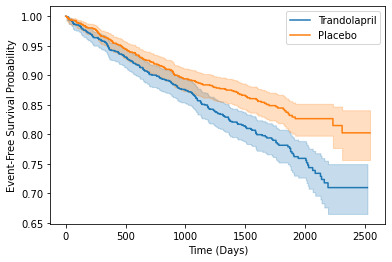

In [44]:
# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax = reporting.plot_kaplanmeier(y_train.iloc[idx_list_0], x_train['TX_1.0'].iloc[idx_list_0])
h, l = ax.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Trandolapril', 'Placebo'], loc="upper right")
plt.show()

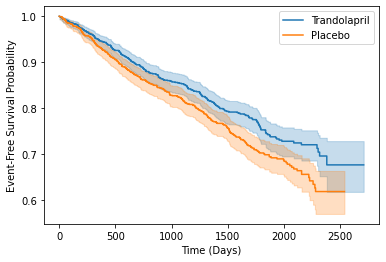

In [45]:
# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax2 = reporting.plot_kaplanmeier(y_train.iloc[idx_list_1], x_train['TX_1.0'].iloc[idx_list_1])
h, l = ax2.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Trandolapril', 'Placebo'], loc="upper right")
plt.show()

In [46]:
zeta_test =  np.argmax(zeta_probs_test, axis=1)
idx_list_0te = np.where(zeta_test == 0)
idx_list_1te = np.where(zeta_test == 1)

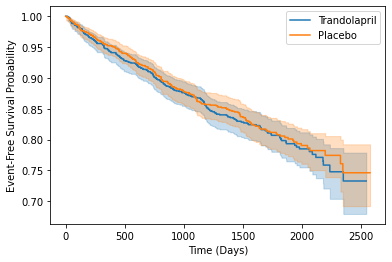

In [47]:
# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax3 = reporting.plot_kaplanmeier(y_test.iloc[idx_list_0te], x_test['TX_1.0'].iloc[idx_list_0te])
h, l = ax3.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Trandolapril', 'Placebo'], loc="upper right")
plt.show()

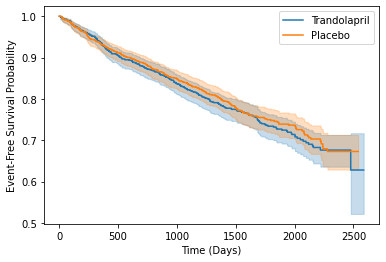

In [48]:
# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax4 = reporting.plot_kaplanmeier(y_test.iloc[idx_list_1te], x_test['TX_1.0'].iloc[idx_list_1te])
h, l = ax4.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Trandolapril', 'Placebo'], loc="upper right")
plt.show()